In [1]:
import jax

In [2]:
rng_key = jax.random.PRNGKey(0)

from datasets import load_dataset
import numpy as np

mnist_data = load_dataset("mnist")
data_train, data_test = mnist_data["train"], mnist_data["test"]

X_train = np.stack([np.array(example["image"]) for example in data_train])
y_train = np.array([example["label"] for example in data_train])

X_test = np.stack([np.array(example["image"]) for example in data_test])
y_test = np.array([example["label"] for example in data_test])


/root/miniconda3/envs/probjax/lib/python3.10/site-packages/datasets/load.py:1486: FutureWarning: The repository for mnist contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/mnist
You can avoid this message in future by passing the argument `trust_remote_code=True`.
Passing `trust_remote_code=True` will be mandatory to load this dataset from the next major release of `datasets`.
  warnings.warn(


In [3]:
import jax.numpy as jnp


def one_hot_encode(x, k):
    "Create a one-hot encoding of x of size k."
    return jnp.array(x[:, None] == jnp.arange(k), dtype=jnp.float32)


@jax.jit
def prepare_data(X, y, num_categories=10):
    y = one_hot_encode(y, num_categories)

    num_examples = X.shape[0]
    num_pixels = 28 * 28
    X = X.reshape(num_examples, num_pixels)
    X = X / 255.0

    return X, y, num_examples


def batch_data(rng_key, data, batch_size, data_size):
    """Return an iterator over batches of data."""
    while True:
        _, rng_key = jax.random.split(rng_key)
        idx = jax.random.choice(
            key=rng_key, a=jnp.arange(data_size), shape=(batch_size,)
        )
        minibatch = tuple(elem[idx] for elem in data)
        yield minibatch


X_train, y_train, N_train = prepare_data(X_train, y_train)
X_test, y_test, N_test = prepare_data(X_test, y_test)

In [4]:
import flax.linen as nn
import jax.scipy.stats as stats


class NN(nn.Module):
    @nn.compact
    def __call__(self, x):
        x = nn.Dense(features=100)(x)
        x = nn.relu(x)
        x = nn.Dense(features=100)(x)
        x = nn.relu(x)
        x = nn.Dense(features=10)(x)
        return nn.log_softmax(x)


model = NN()


def logprior_fn(params):
    """Compute the value of the log-prior density function."""
    leaves, _ = jax.tree_util.tree_flatten(params)
    flat_params = jnp.concatenate([jnp.ravel(a) for a in leaves])
    return jnp.sum(stats.norm.logpdf(flat_params))


def loglikelihood_fn(params, data):
    """Categorical log-likelihood"""
    X, y = data
    return jnp.sum(y * model.apply(params, X))


@jax.jit
def compute_accuracy(params, X, y):
    """Compute the accuracy of the model.

    To make predictions we take the number that corresponds to the highest
    probability value, which corresponds to a 1-0 loss.

    """
    target_class = jnp.argmax(y, axis=1)
    predicted_class = jnp.argmax(model.apply(params, X), axis=1)
    return jnp.mean(predicted_class == target_class)

In [6]:
from fastprogress.fastprogress import progress_bar

import blackjax
from blackjax.sgmcmc.gradients import grad_estimator
from blackjax.smc import adaptive_tempered


data_size = len(y_train)
batch_size = 512
step_size = 1e-6

num_warmup = (data_size // batch_size) * 100
num_samples = 1000

rng_key, batch_key, init_key = jax.random.split(rng_key, 3)
# Batch the data
batches = batch_data(batch_key, (X_train, y_train), batch_size, data_size)

# Set the initial state
state = jax.jit(model.init)(init_key, jnp.ones(X_train.shape[-1]))

# Build the SGLD kernel with a constant learning rate
grad_fn = grad_estimator(logprior_fn, loglikelihood_fn, data_size)
sgld = blackjax.sgld(grad_fn)

# Sample from the posterior
accuracies = []
steps = []

pb = progress_bar(range(num_warmup))
for step in pb:
    rng_key, sample_key = jax.random.split(rng_key)
    batch = next(batches)
    state = jax.jit(sgld.step)(sample_key, state, batch, step_size)
    if step % 100 == 0:
        accuracy = compute_accuracy(state, X_test, y_test)
        accuracies.append(accuracy)
        steps.append(step)
        pb.comment = f"| error: {100*(1-accuracy): .1f}"

KeyboardInterrupt: 

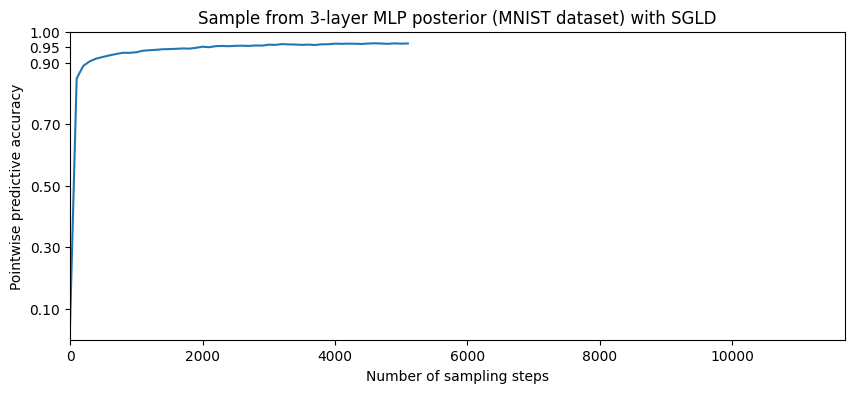

In [7]:
import matplotlib.pyplot as plt

_, ax = plt.subplots(figsize=(10, 4))
ax.plot(steps, accuracies)
ax.set_xlabel("Number of sampling steps")
ax.set_ylabel("Pointwise predictive accuracy")
ax.set_xlim([0, num_warmup])
ax.set_ylim([0, 1])
ax.set_yticks([0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0])
plt.title("Sample from 3-layer MLP posterior (MNIST dataset) with SGLD");

In [8]:
@jax.jit
def update_test_accuracy(i, logpredictprob, sample):
    """Update the running average log-predictive probability
    and return the current value of the accuracy.

    """
    new_logpredictprob = jnp.logaddexp(
        logpredictprob, jax.vmap(model.apply, in_axes=(None, 0))(sample, X_test)
    )
    predict_probs = jnp.exp(new_logpredictprob) / (i + 1)

    predicted = jnp.argmax(predict_probs, axis=1)
    target = jnp.argmax(y_test, axis=1)
    accuracy = jnp.mean(predicted == target)

    return new_logpredictprob, accuracy

In [9]:
sgld_accuracies = []
sgld_logpredict = jax.vmap(model.apply, in_axes=(None, 0))(state, X_test)
num_samples = 5000

pb = progress_bar(range(num_samples))
for step in pb:
    rng_key, sample_key = jax.random.split(rng_key)
    batch = next(batches)
    state = jax.jit(sgld.step)(sample_key, state, batch, step_size)
    sgld_logpredict, accuracy = update_test_accuracy(step, sgld_logpredict, state)
    sgld_accuracies.append(accuracy)
    pb.comment = f"| avg error: {100*(1-accuracy): .1f}"

StopIteration: 

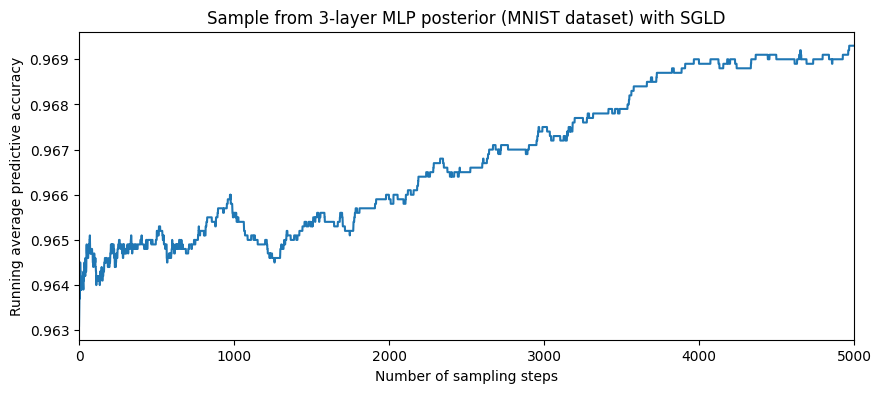

In [15]:
_, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(num_samples), sgld_accuracies)
ax.set_xlabel("Number of sampling steps")
ax.set_ylabel("Running average predictive accuracy")
ax.set_xlim([0, num_samples])
plt.title("Sample from 3-layer MLP posterior (MNIST dataset) with SGLD");

In [32]:
step_size = 1e-4
num_warmup = (data_size // batch_size) * 50

batches = batch_data(batch_key, (X_train, y_train), batch_size, data_size)

grad_fn = grad_estimator(logprior_fn, loglikelihood_fn, data_size)
sghmc = blackjax.sghmc(grad_fn, num_integration_steps=10)

rng_key, batch_key = jax.random.split(rng_key)
# Batch the data
state = jax.jit(model.init)(batch_key, jnp.ones(X_train.shape[-1]))

# Sample from the posterior
sghmc_accuracies = []
samples = []
steps = []

pb = progress_bar(range(num_warmup))
for step in pb:
    rng_key, sample_key = jax.random.split(rng_key)
    minibatch = next(batches)
    state = jax.jit(sghmc.step)(sample_key, state, minibatch, step_size)
    if step % 100 == 0:
        sghmc_accuracy = compute_accuracy(state, X_test, y_test)
        sghmc_accuracies.append(sghmc_accuracy)
        steps.append(step)
        pb.comment = f"| error: {100*(1-sghmc_accuracy): .1f}"

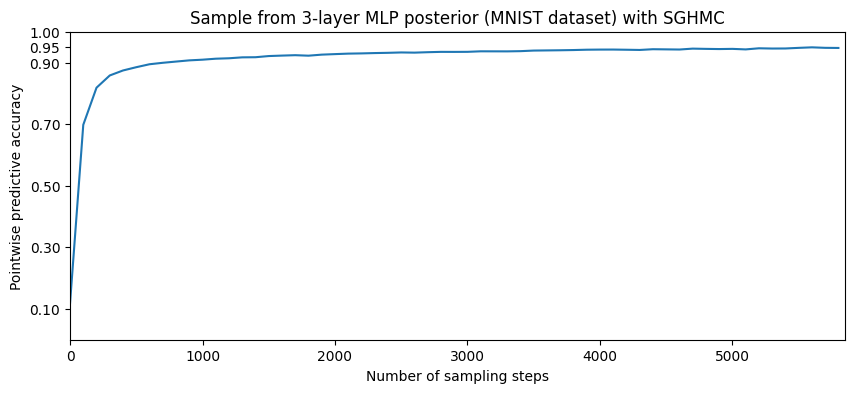

In [34]:
_, ax = plt.subplots(figsize=(10, 4))
ax.plot(steps, sghmc_accuracies)
ax.set_xlabel("Number of sampling steps")
ax.set_ylabel("Pointwise predictive accuracy")
ax.set_xlim([0, num_warmup])
ax.set_ylim([0, 1])
ax.set_yticks([0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0])
plt.title("Sample from 3-layer MLP posterior (MNIST dataset) with SGHMC");

In [35]:
sghmc_accuracies = []
sghmc_logpredict = jax.vmap(model.apply, in_axes=(None, 0))(state, X_test)

pb = progress_bar(range(num_samples))
for step in pb:
    rng_key, sample_key = jax.random.split(rng_key)
    batch = next(batches)
    state = jax.jit(sghmc.step)(sample_key, state, batch, step_size)
    sghmc_logpredict, accuracy = update_test_accuracy(step, sghmc_logpredict, state)
    sghmc_accuracies.append(accuracy)
    pb.comment = f"| avg error: {100*(1-accuracy): .1f}"

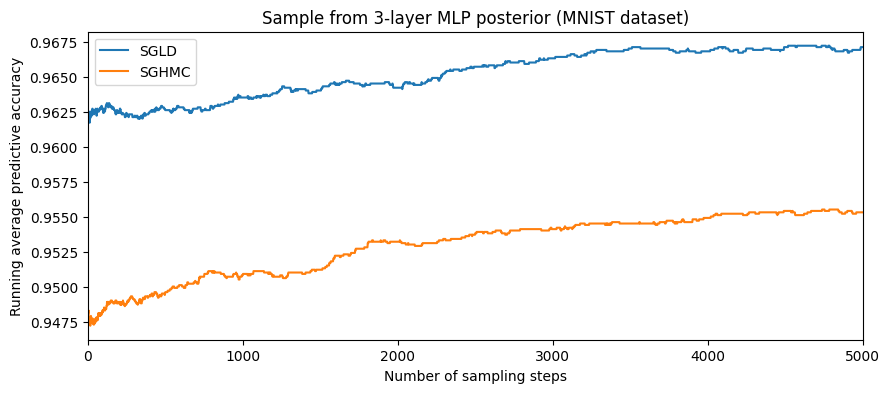

In [36]:
_, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(num_samples), sgld_accuracies, label="SGLD")
ax.plot(range(num_samples), sghmc_accuracies, label="SGHMC")
ax.set_xlabel("Number of sampling steps")
ax.set_ylabel("Running average predictive accuracy")
ax.set_xlim([0, num_samples])
plt.title("Sample from 3-layer MLP posterior (MNIST dataset)")
plt.legend();